In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, confusion_matrix, 
                           classification_report, roc_curve, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

class FeatureSelectionAnalyzer:
    def __init__(self, X, y, test_size=0.2, random_state=42):
        """
        Инициализация анализатора отбора признаков
        
        Parameters:
        -----------
        X : pandas.DataFrame
            Матрица признаков
        y : pandas.Series или numpy.array
            Целевая переменная (бинарная классификация)
        test_size : float, default=0.2
            Размер тестовой выборки
        random_state : int, default=42
            Фиксатор случайности
        """
        self.X = X
        self.y = y
        self.test_size = test_size
        self.random_state = random_state
        
        # Разделение данных
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        
        # Хранение результатов
        self.forward_results = {}
        self.backward_results = {}
        self.best_threshold = 0.5  # по умолчанию
        
    def _evaluate_model(self, model, features, method_name, step):
        """
        Оценка модели и сохранение результатов
        """
        start_time = time.time()
        
        # Обучение модели
        X_train_subset = self.X_train[features]
        X_test_subset = self.X_test[features]
        
        model.fit(X_train_subset, self.y_train)
        
        # Предсказания
        y_pred_proba = model.predict_proba(X_test_subset)[:, 1]
        y_pred = (y_pred_proba >= self.best_threshold).astype(int)
        
        # Расчет метрик
        metrics = {
            'accuracy': accuracy_score(self.y_test, y_pred),
            'precision': precision_score(self.y_test, y_pred),
            'recall': recall_score(self.y_test, y_pred),
            'f1': f1_score(self.y_test, y_pred),
            'roc_auc': roc_auc_score(self.y_test, y_pred_proba),
            'training_time': time.time() - start_time
        }
        
        # Важность признаков (если доступно)
        feature_importance = {}
        if hasattr(model, 'feature_importances_'):
            feature_importance = dict(zip(features, model.feature_importances_))
        elif hasattr(model, 'coef_'):
            feature_importance = dict(zip(features, np.abs(model.coef_[0])))
        
        # Сохранение результатов
        result = {
            'step': step,
            'features': features.copy(),
            'n_features': len(features),
            'metrics': metrics,
            'feature_importance': feature_importance,
            'y_pred_proba': y_pred_proba.copy(),
            'y_pred': y_pred.copy(),
            'y_true': self.y_test.copy(),
            'model': model.__class__.__name__
        }
        
        return result, y_pred_proba
    
    def forward_selection(self, model, max_features=None, cv=3):
        """
        Forward Selection с сохранением всех результатов
        
        Parameters:
        -----------
        model : sklearn estimator
            Модель для обучения
        max_features : int, optional
            Максимальное количество признаков для отбора
        cv : int, default=3
            Количество фолдов для кросс-валидации (необязательно)
        """
        print("Запуск Forward Selection...")
        
        all_features = list(self.X.columns)
        if max_features is None:
            max_features = len(all_features)
            
        selected_features = []
        remaining_features = all_features.copy()
        best_roc_auc = -np.inf
        step = 0
        
        pbar = tqdm(total=min(max_features, len(all_features)))
        
        while len(selected_features) < max_features and remaining_features:
            step += 1
            best_feature = None
            best_score = -np.inf
            
            for feature in remaining_features:
                candidate_features = selected_features + [feature]
                
                # Обучение и оценка
                result, _ = self._evaluate_model(model, candidate_features, 'forward', step)
                current_roc_auc = result['metrics']['roc_auc']
                
                if current_roc_auc > best_score:
                    best_score = current_roc_auc
                    best_feature = feature
                    best_result = result
            
            # Проверка улучшения
            if best_score > best_roc_auc:
                best_roc_auc = best_score
                selected_features.append(best_feature)
                remaining_features.remove(best_feature)
                
                # Сохранение результатов
                self.forward_results[len(selected_features)] = best_result
                print(f"Step {step}: Добавлен признак '{best_feature}', ROC AUC: {best_score:.4f}")
            else:
                print(f"Step {step}: Нет улучшений, останавливаемся")
                break
            
            pbar.update(1)
            pbar.set_postfix({'ROC AUC': f'{best_score:.4f}', 'Features': len(selected_features)})
        
        pbar.close()
        print(f"Forward Selection завершен. Выбрано признаков: {len(selected_features)}")
        return selected_features
    
    def backward_elimination(self, model, min_features=1):
        """
        Backward Elimination с сохранением всех результатов
        
        Parameters:
        -----------
        model : sklearn estimator
            Модель для обучения
        min_features : int, default=1
            Минимальное количество признаков
        """
        print("Запуск Backward Elimination...")
        
        selected_features = list(self.X.columns)
        best_roc_auc = -np.inf
        step = 0
        
        pbar = tqdm(total=len(selected_features) - min_features)
        
        while len(selected_features) > min_features:
            step += 1
            worst_feature = None
            best_score = -np.inf
            
            for feature in selected_features:
                candidate_features = [f for f in selected_features if f != feature]
                
                # Обучение и оценка
                result, _ = self._evaluate_model(model, candidate_features, 'backward', step)
                current_roc_auc = result['metrics']['roc_auc']
                
                if current_roc_auc > best_score:
                    best_score = current_roc_auc
                    worst_feature = feature
                    best_result = result
            
            # Проверка улучшения
            if best_score > best_roc_auc:
                best_roc_auc = best_score
                selected_features.remove(worst_feature)
                
                # Сохранение результатов
                self.backward_results[len(selected_features)] = best_result
                print(f"Step {step}: Удален признак '{worst_feature}', ROC AUC: {best_score:.4f}")
            else:
                print(f"Step {step}: Удаление ухудшает результат, останавливаемся")
                break
            
            pbar.update(1)
            pbar.set_postfix({'ROC AUC': f'{best_score:.4f}', 'Features': len(selected_features)})
        
        pbar.close()
        print(f"Backward Elimination завершен. Осталось признаков: {len(selected_features)}")
        return selected_features
    
    def find_optimal_threshold(self, method='forward', n_features=None):
        """
        Поиск оптимального порога для бинарной классификации
        
        Parameters:
        -----------
        method : str, 'forward' or 'backward'
            Метод отбора признаков
        n_features : int, optional
            Количество признаков для анализа
        """
        if method == 'forward' and n_features is None:
            n_features = max(self.forward_results.keys())
        elif method == 'backward' and n_features is None:
            n_features = min(self.backward_results.keys())
        
        if method == 'forward':
            result = self.forward_results[n_features]
        else:
            result = self.backward_results[n_features]
        
        y_true = result['y_true']
        y_pred_proba = result['y_pred_proba']
        
        # Поиск оптимального порога по F1
        thresholds = np.arange(0.1, 0.9, 0.01)
        best_f1 = -1
        best_threshold = 0.5
        
        for threshold in thresholds:
            y_pred = (y_pred_proba >= threshold).astype(int)
            f1 = f1_score(y_true, y_pred)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
        
        # Дополнительно: оптимальный порог по Youden's J statistic
        fpr, tpr, thresholds_roc = roc_curve(y_true, y_pred_proba)
        j_scores = tpr - fpr
        best_j_threshold = thresholds_roc[np.argmax(j_scores)]
        
        self.best_threshold = best_threshold
        
        print(f"=== Оптимальные пороги ({method}, {n_features} признаков) ===")
        print(f"По F1 score: {best_threshold:.4f} (F1={best_f1:.4f})")
        print(f"По Youden's J: {best_j_threshold:.4f}")
        
        return best_threshold, best_j_threshold
    
    def visualize_probability_distribution(self, method='forward', n_features=None):
        """
        Визуализация распределения вероятностей
        
        Parameters:
        -----------
        method : str, 'forward' or 'backward'
            Метод отбора признаков
        n_features : int, optional
            Количество признаков для визуализации
        """
        if method == 'forward' and n_features is None:
            n_features = max(self.forward_results.keys())
        elif method == 'backward' and n_features is None:
            n_features = min(self.backward_results.keys())
        
        if method == 'forward':
            result = self.forward_results[n_features]
        else:
            result = self.backward_results[n_features]
        
        y_true = result['y_true']
        y_pred_proba = result['y_pred_proba']
        
        plt.figure(figsize=(15, 10))
        
        # 1. Распределение вероятностей для каждого класса
        plt.subplot(2, 2, 1)
        sns.histplot(data=pd.DataFrame({
            'Probability': y_pred_proba,
            'Class': ['Positive' if x == 1 else 'Negative' for x in y_true]
        }), x='Probability', hue='Class', bins=30, kde=True, alpha=0.6)
        plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
        if hasattr(self, 'best_threshold'):
            plt.axvline(x=self.best_threshold, color='g', linestyle='-', alpha=0.7, 
                       label=f'Optimal threshold ({self.best_threshold:.3f})')
        plt.title(f'Распределение вероятностей ({method}, {n_features} признаков)')
        plt.xlabel('Вероятность класса 1')
        plt.ylabel('Частота')
        plt.legend()
        
        # 2. ROC кривая
        plt.subplot(2, 2, 2)
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
        roc_auc = roc_auc_score(y_true, y_pred_proba)
        
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC кривая')
        plt.legend(loc="lower right")
        
        # 3. Precision-Recall кривая
        plt.subplot(2, 2, 3)
        precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
        plt.plot(recall, precision, color='blue', lw=2)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall кривая')
        plt.grid(True)
        
        # 4. Матрица ошибок с оптимальным порогом
        plt.subplot(2, 2, 4)
        y_pred_optimal = (y_pred_proba >= self.best_threshold).astype(int)
        cm = confusion_matrix(y_true, y_pred_optimal)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Predicted Negative', 'Predicted Positive'],
                   yticklabels=['Actual Negative', 'Actual Positive'])
        plt.title(f'Матрица ошибок (threshold={self.best_threshold:.3f})')
        
        plt.tight_layout()
        plt.show()
        
        # Дополнительная визуализация: распределение вероятностей по квантилям
        plt.figure(figsize=(12, 6))
        df_probs = pd.DataFrame({
            'Probability': y_pred_proba,
            'Class': y_true
        })
        
        plt.subplot(1, 2, 1)
        sns.boxplot(x='Class', y='Probability', data=df_probs)
        plt.title('Boxplot вероятностей по классам')
        plt.xlabel('Класс')
        plt.ylabel('Вероятность')
        
        plt.subplot(1, 2, 2)
        # Квантили вероятностей
        quantiles = np.percentile(y_pred_proba, [0, 25, 50, 75, 100])
        plt.hist(y_pred_proba, bins=20, alpha=0.7, edgecolor='black')
        for q in quantiles:
            plt.axvline(x=q, color='r', linestyle='--', alpha=0.5)
        plt.title('Гистограмма вероятностей с квантилями')
        plt.xlabel('Вероятность')
        plt.ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
    
    def compare_feature_selection_methods(self):
        """
        Сравнение результатов forward selection и backward elimination
        """
        if not self.forward_results and not self.backward_results:
            print("Нет результатов для сравнения. Запустите сначала forward_selection и backward_elimination.")
            return
        
        plt.figure(figsize=(15, 10))
        
        # 1. Сравнение ROC AUC по количеству признаков
        plt.subplot(2, 2, 1)
        
        if self.forward_results:
            forward_x = sorted(self.forward_results.keys())
            forward_y = [self.forward_results[x]['metrics']['roc_auc'] for x in forward_x]
            plt.plot(forward_x, forward_y, 'o-', label='Forward Selection', color='blue')
        
        if self.backward_results:
            backward_x = sorted(self.backward_results.keys())
            backward_y = [self.backward_results[x]['metrics']['roc_auc'] for x in backward_x]
            plt.plot(backward_x, backward_y, 's-', label='Backward Elimination', color='red')
        
        plt.xlabel('Количество признаков')
        plt.ylabel('ROC AUC')
        plt.title('Сравнение ROC AUC по количеству признаков')
        plt.legend()
        plt.grid(True)
        
        # 2. Сравнение F1 score
        plt.subplot(2, 2, 2)
        
        if self.forward_results:
            forward_f1 = [self.forward_results[x]['metrics']['f1'] for x in forward_x]
            plt.plot(forward_x, forward_f1, 'o-', label='Forward Selection', color='blue')
        
        if self.backward_results:
            backward_f1 = [self.backward_results[x]['metrics']['f1'] for x in backward_x]
            plt.plot(backward_x, backward_f1, 's-', label='Backward Elimination', color='red')
        
        plt.xlabel('Количество признаков')
        plt.ylabel('F1 Score')
        plt.title('Сравнение F1 Score по количеству признаков')
        plt.legend()
        plt.grid(True)
        
        # 3. Время обучения
        plt.subplot(2, 2, 3)
        
        if self.forward_results:
            forward_time = [self.forward_results[x]['metrics']['training_time'] for x in forward_x]
            plt.plot(forward_x, forward_time, 'o-', label='Forward Selection', color='blue')
        
        if self.backward_results:
            backward_time = [self.backward_results[x]['metrics']['training_time'] for x in backward_x]
            plt.plot(backward_x, backward_time, 's-', label='Backward Elimination', color='red')
        
        plt.xlabel('Количество признаков')
        plt.ylabel('Время обучения (сек)')
        plt.title('Сравнение времени обучения')
        plt.legend()
        plt.grid(True)
        
        # 4. Сравнение важности признаков для лучших моделей
        plt.subplot(2, 2, 4)
        
        best_forward = max(self.forward_results.items(), key=lambda x: x[1]['metrics']['roc_auc'])[1]
        best_backward = max(self.backward_results.items(), key=lambda x: x[1]['metrics']['roc_auc'])[1]
        
        # Объединяем важность признаков
        all_features = set(list(best_forward['feature_importance'].keys()) + 
                          list(best_backward['feature_importance'].keys()))
        
        forward_importance = [best_forward['feature_importance'].get(f, 0) for f in all_features]
        backward_importance = [best_backward['feature_importance'].get(f, 0) for f in all_features]
        
        x = np.arange(len(all_features))
        width = 0.35
        
        plt.bar(x - width/2, forward_importance, width, label='Forward Selection')
        plt.bar(x + width/2, backward_importance, width, label='Backward Elimination')
        plt.xlabel('Признаки')
        plt.ylabel('Важность')
        plt.title('Сравнение важности признаков')
        plt.xticks(x, list(all_features), rotation=45, ha='right')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    def get_best_features(self, method='forward', metric='roc_auc'):
        """
        Получение лучших признаков по заданной метрике
        
        Parameters:
        -----------
        method : str, 'forward' or 'backward'
            Метод отбора признаков
        metric : str, default='roc_auc'
            Метрика для выбора лучших признаков
        """
        if method == 'forward':
            results = self.forward_results
        else:
            results = self.backward_results
        
        if not results:
            print(f"Нет результатов для метода {method}. Запустите сначала отбор признаков.")
            return None
        
        # Находим лучший результат по метрике
        best_result = max(results.items(), key=lambda x: x[1]['metrics'][metric])[1]
        
        print(f"=== Лучшие признаки ({method}) ===")
        print(f"Количество признаков: {best_result['n_features']}")
        print(f"Лучшая {metric}: {best_result['metrics'][metric]:.4f}")
        print(f"Признаки: {best_result['features']}")
        
        if best_result['feature_importance']:
            print("\nВажность признаков:")
            sorted_importance = sorted(best_result['feature_importance'].items(), 
                                     key=lambda x: x[1], reverse=True)
            for feature, importance in sorted_importance:
                print(f"  {feature}: {importance:.4f}")
        
        return best_result['features'], best_result
    
    def save_results_to_excel(self, filename='feature_selection_results.xlsx'):
        """
        Сохранение всех результатов в Excel файл
        
        Parameters:
        -----------
        filename : str, default='feature_selection_results.xlsx'
            Имя файла для сохранения
        """
        with pd.ExcelWriter(filename) as writer:
            # Forward Selection results
            if self.forward_results:
                forward_df = []
                for n_features, result in self.forward_results.items():
                    row = {
                        'Method': 'Forward',
                        'Step': result['step'],
                        'N_Features': result['n_features'],
                        'Features': ', '.join(result['features']),
                        'Accuracy': result['metrics']['accuracy'],
                        'Precision': result['metrics']['precision'],
                        'Recall': result['metrics']['recall'],
                        'F1': result['metrics']['f1'],
                        'ROC_AUC': result['metrics']['roc_auc'],
                        'Training_Time': result['metrics']['training_time']
                    }
                    
                    # Добавляем важность признаков
                    for feature, importance in result['feature_importance'].items():
                        row[f'Importance_{feature}'] = importance
                    
                    forward_df.append(row)
                
                pd.DataFrame(forward_df).to_excel(writer, sheet_name='Forward_Selection', index=False)
            
            # Backward Elimination results
            if self.backward_results:
                backward_df = []
                for n_features, result in self.backward_results.items():
                    row = {
                        'Method': 'Backward',
                        'Step': result['step'],
                        'N_Features': result['n_features'],
                        'Features': ', '.join(result['features']),
                        'Accuracy': result['metrics']['accuracy'],
                        'Precision': result['metrics']['precision'],
                        'Recall': result['metrics']['recall'],
                        'F1': result['metrics']['f1'],
                        'ROC_AUC': result['metrics']['roc_auc'],
                        'Training_Time': result['metrics']['training_time']
                    }
                    
                    # Добавляем важность признаков
                    for feature, importance in result['feature_importance'].items():
                        row[f'Importance_{feature}'] = importance
                    
                    backward_df.append(row)
                
                pd.DataFrame(backward_df).to_excel(writer, sheet_name='Backward_Elimination', index=False)
            
            # Сравнение результатов
            if self.forward_results and self.backward_results:
                comparison_data = []
                
                # Лучшие результаты для каждого метода
                best_forward = max(self.forward_results.items(), key=lambda x: x[1]['metrics']['roc_auc'])[1]
                best_backward = max(self.backward_results.items(), key=lambda x: x[1]['metrics']['roc_auc'])[1]
                
                comparison_data.append({
                    'Method': 'Forward_Selection',
                    'N_Features': best_forward['n_features'],
                    'Features': ', '.join(best_forward['features']),
                    'ROC_AUC': best_forward['metrics']['roc_auc'],
                    'F1': best_forward['metrics']['f1'],
                    'Accuracy': best_forward['metrics']['accuracy']
                })
                
                comparison_data.append({
                    'Method': 'Backward_Elimination',
                    'N_Features': best_backward['n_features'],
                    'Features': ', '.join(best_backward['features']),
                    'ROC_AUC': best_backward['metrics']['roc_auc'],
                    'F1': best_backward['metrics']['f1'],
                    'Accuracy': best_backward['metrics']['accuracy']
                })
                
                pd.DataFrame(comparison_data).to_excel(writer, sheet_name='Best_Results_Comparison', index=False)
        
        print(f"Результаты успешно сохранены в файл: {filename}")


# Пример использования:

# Загрузка данных (пример)
# from sklearn.datasets import make_classification

# # Генерация примера данных
# X, y = make_classification(
#     n_samples=1000,
#     n_features=20,
#     n_informative=10,
#     n_redundant=5,
#     n_classes=2,
#     random_state=42
# )

# feature_names = [f'feature_{i}' for i in range(20)]
# X_df = pd.DataFrame(X, columns=feature_names)
# y_series = pd.Series(y)

# # Инициализация анализатора
# analyzer = FeatureSelectionAnalyzer(X_df, y_series, test_size=0.2, random_state=42)

# # Выбор модели
# model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# # Запуск forward selection
# print("=== FORWARD SELECTION ===")
# forward_features = analyzer.forward_selection(model_rf, max_features=15)

# # Запуск backward elimination
# print("\n=== BACKWARD ELIMINATION ===")
# backward_features = analyzer.backward_elimination(model_rf, min_features=5)

# # Сравнение методов
# print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
# analyzer.compare_feature_selection_methods()

# # Поиск оптимального порога для лучшей модели forward selection
# print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
# best_threshold, _ = analyzer.find_optimal_threshold(method='forward')

# # Визуализация распределения вероятностей
# print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
# analyzer.visualize_probability_distribution(method='forward')

# # Получение лучших признаков
# print("\n=== ЛУЧШИЕ ПРИЗНАКИ ===")
# best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
# best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')

# # Сохранение результатов
# print("\n=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===")
# analyzer.save_results_to_excel('feature_selection_analysis.xlsx')

# print("\n=== ЗАКЛЮЧЕНИЕ ===")
# print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
# print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
# print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, confusion_matrix, 
                           classification_report, roc_curve, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

class FeatureSelectionAnalyzer:
    def __init__(self, X, y, test_size=0.2, random_state=42):
        """
        Инициализация анализатора отбора признаков
        
        Parameters:
        -----------
        X : pandas.DataFrame
            Матрица признаков
        y : pandas.Series или numpy.array
            Целевая переменная (бинарная классификация)
        test_size : float, default=0.2
            Размер тестовой выборки
        random_state : int, default=42
            Фиксатор случайности
        """
        self.X = X
        self.y = y
        self.test_size = test_size
        self.random_state = random_state
        
        # Разделение данных
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        
        # Хранение результатов
        self.forward_results = {}
        self.backward_results = {}
        self.best_threshold = 0.5  # по умолчанию
        
    def _evaluate_model(self, model, features, method_name, step):
        """
        Оценка модели и сохранение результатов
        """
        start_time = time.time()
        
        # Обучение модели
        X_train_subset = self.X_train[features]
        X_test_subset = self.X_test[features]
        
        model.fit(X_train_subset, self.y_train)
        
        # Предсказания
        y_pred_proba = model.predict_proba(X_test_subset)[:, 1]
        y_pred = (y_pred_proba >= self.best_threshold).astype(int)
        
        # Расчет метрик
        metrics = {
            'accuracy': accuracy_score(self.y_test, y_pred),
            'precision': precision_score(self.y_test, y_pred),
            'recall': recall_score(self.y_test, y_pred),
            'f1': f1_score(self.y_test, y_pred),
            'roc_auc': roc_auc_score(self.y_test, y_pred_proba),
            'training_time': time.time() - start_time
        }
        
        # Важность признаков (если доступно)
        feature_importance = {}
        if hasattr(model, 'feature_importances_'):
            feature_importance = dict(zip(features, model.feature_importances_))
        elif hasattr(model, 'coef_'):
            feature_importance = dict(zip(features, np.abs(model.coef_[0])))
        
        # Сохранение результатов
        result = {
            'step': step,
            'features': features.copy(),
            'n_features': len(features),
            'metrics': metrics,
            'feature_importance': feature_importance,
            'y_pred_proba': y_pred_proba.copy(),
            'y_pred': y_pred.copy(),
            'y_true': self.y_test.copy(),
            'model': model.__class__.__name__
        }
        
        return result, y_pred_proba
    
    def forward_selection(self, model, max_features=None):
        """
        Forward Selection без early stopping - перебирает все комбинации
        
        Parameters:
        -----------
        model : sklearn estimator
            Модель для обучения
        max_features : int, optional
            Максимальное количество признаков для отбора. Если None, использует все признаки.
        """
        print("Запуск Forward Selection (без early stopping)...")
        
        all_features = list(self.X.columns)
        if max_features is None or max_features > len(all_features):
            max_features = len(all_features)
            
        selected_features = []
        remaining_features = all_features.copy()
        step = 0
        
        pbar = tqdm(total=min(max_features, len(all_features)))
        
        while len(selected_features) < max_features and remaining_features:
            step += 1
            best_feature = None
            best_score = -np.inf
            
            # Находим лучший признак для добавления на текущем шаге
            for feature in remaining_features:
                candidate_features = selected_features + [feature]
                
                # Обучение и оценка
                result, _ = self._evaluate_model(model, candidate_features, 'forward', step)
                current_roc_auc = result['metrics']['roc_auc']
                
                if current_roc_auc > best_score:
                    best_score = current_roc_auc
                    best_feature = feature
                    best_result = result
            
            # ВСЕГДА добавляем лучший признак на текущем шаге, даже если метрика ухудшилась
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            
            # Сохранение результатов для текущего количества признакей
            self.forward_results[len(selected_features)] = best_result
            
            print(f"Step {step}: Добавлен признак '{best_feature}', ROC AUC: {best_score:.4f}, "
                  f"Всего признакей: {len(selected_features)}")
            
            pbar.update(1)
            pbar.set_postfix({'ROC AUC': f'{best_score:.4f}', 'Features': len(selected_features)})
        
        pbar.close()
        print(f"Forward Selection завершен. Обработано всех возможных признакей: {len(selected_features)}")
        return selected_features
    
    def backward_elimination(self, model, min_features=1):
        """
        Backward Elimination без early stopping - перебирает все комбинации
        
        Parameters:
        -----------
        model : sklearn estimator
            Модель для обучения
        min_features : int, default=1
            Минимальное количество признакей, до которого продолжать удаление
        """
        print("Запуск Backward Elimination (без early stopping)...")
        
        selected_features = list(self.X.columns)
        step = 0
        
        pbar = tqdm(total=len(selected_features) - min_features)
        
        # Начальная оценка со всеми признаками
        initial_result, _ = self._evaluate_model(model, selected_features, 'backward', 0)
        self.backward_results[len(selected_features)] = initial_result
        print(f"Начальное состояние: {len(selected_features)} признакей, ROC AUC: {initial_result['metrics']['roc_auc']:.4f}")
        
        while len(selected_features) > min_features:
            step += 1
            worst_feature = None
            best_score = -np.inf
            
            # Находим признак, удаление которого дает лучший результат
            for feature in selected_features:
                candidate_features = [f for f in selected_features if f != feature]
                
                # Обучение и оценка
                result, _ = self._evaluate_model(model, candidate_features, 'backward', step)
                current_roc_auc = result['metrics']['roc_auc']
                
                if current_roc_auc > best_score:
                    best_score = current_roc_auc
                    worst_feature = feature
                    best_result = result
            
            # ВСЕГДА удаляем "худший" признак (тот, удаление которого дает лучший результат), даже если метрика ухудшилась
            selected_features.remove(worst_feature)
            
            # Сохранение результатов для текущего количества признакей
            self.backward_results[len(selected_features)] = best_result
            
            print(f"Step {step}: Удален признак '{worst_feature}', ROC AUC: {best_score:.4f}, "
                  f"Осталось признакей: {len(selected_features)}")
            
            pbar.update(1)
            pbar.set_postfix({'ROC AUC': f'{best_score:.4f}', 'Features': len(selected_features)})
        
        pbar.close()
        print(f"Backward Elimination завершен. Достигнуто минимальное количество признакей: {len(selected_features)}")
        return selected_features
    
    def find_optimal_threshold(self, method='forward', n_features=None):
        """
        Поиск оптимального порога для бинарной классификации
        
        Parameters:
        -----------
        method : str, 'forward' or 'backward'
            Метод отбора признакей
        n_features : int, optional
            Количество признакей для анализа
        """
        if method == 'forward' and n_features is None:
            n_features = max(self.forward_results.keys())
        elif method == 'backward' and n_features is None:
            n_features = min(self.backward_results.keys())
        
        if method == 'forward' and n_features not in self.forward_results:
            raise ValueError(f"Результаты для {n_features} признакей в forward selection не найдены")
        elif method == 'backward' and n_features not in self.backward_results:
            raise ValueError(f"Результаты для {n_features} признакей в backward elimination не найдены")
        
        if method == 'forward':
            result = self.forward_results[n_features]
        else:
            result = self.backward_results[n_features]
        
        y_true = result['y_true']
        y_pred_proba = result['y_pred_proba']
        
        # Поиск оптимального порога по F1
        thresholds = np.arange(0.1, 0.9, 0.01)
        best_f1 = -1
        best_threshold = 0.5
        
        for threshold in thresholds:
            y_pred = (y_pred_proba >= threshold).astype(int)
            f1 = f1_score(y_true, y_pred)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
        
        # Дополнительно: оптимальный порог по Youden's J statistic
        fpr, tpr, thresholds_roc = roc_curve(y_true, y_pred_proba)
        j_scores = tpr - fpr
        best_j_threshold = thresholds_roc[np.argmax(j_scores)]
        
        self.best_threshold = best_threshold
        
        print(f"=== Оптимальные пороги ({method}, {n_features} признакей) ===")
        print(f"По F1 score: {best_threshold:.4f} (F1={best_f1:.4f})")
        print(f"По Youden's J: {best_j_threshold:.4f}")
        
        return best_threshold, best_j_threshold
    
    def visualize_probability_distribution(self, method='forward', n_features=None):
        """
        Визуализация распределения вероятностей
        
        Parameters:
        -----------
        method : str, 'forward' or 'backward'
            Метод отбора признакей
        n_features : int, optional
            Количество признакей для визуализации
        """
        if method == 'forward' and n_features is None:
            n_features = max(self.forward_results.keys())
        elif method == 'backward' and n_features is None:
            n_features = min(self.backward_results.keys())
        
        if method == 'forward' and n_features not in self.forward_results:
            raise ValueError(f"Результаты для {n_features} признакей в forward selection не найдены")
        elif method == 'backward' and n_features not in self.backward_results:
            raise ValueError(f"Результаты для {n_features} признакей в backward elimination не найдены")
        
        if method == 'forward':
            result = self.forward_results[n_features]
        else:
            result = self.backward_results[n_features]
        
        y_true = result['y_true']
        y_pred_proba = result['y_pred_proba']
        
        plt.figure(figsize=(15, 10))
        
        # 1. Распределение вероятностей для каждого класса
        plt.subplot(2, 2, 1)
        sns.histplot(data=pd.DataFrame({
            'Probability': y_pred_proba,
            'Class': ['Positive' if x == 1 else 'Negative' for x in y_true]
        }), x='Probability', hue='Class', bins=30, kde=True, alpha=0.6)
        plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
        if hasattr(self, 'best_threshold'):
            plt.axvline(x=self.best_threshold, color='g', linestyle='-', alpha=0.7, 
                       label=f'Optimal threshold ({self.best_threshold:.3f})')
        plt.title(f'Распределение вероятностей ({method}, {n_features} признакей)')
        plt.xlabel('Вероятность класса 1')
        plt.ylabel('Частота')
        plt.legend()
        
        # 2. ROC кривая
        plt.subplot(2, 2, 2)
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
        roc_auc = roc_auc_score(y_true, y_pred_proba)
        
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC кривая')
        plt.legend(loc="lower right")
        
        # 3. Precision-Recall кривая
        plt.subplot(2, 2, 3)
        precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
        plt.plot(recall, precision, color='blue', lw=2)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall кривая')
        plt.grid(True)
        
        # 4. Матрица ошибок с оптимальным порогом
        plt.subplot(2, 2, 4)
        y_pred_optimal = (y_pred_proba >= self.best_threshold).astype(int)
        cm = confusion_matrix(y_true, y_pred_optimal)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Predicted Negative', 'Predicted Positive'],
                   yticklabels=['Actual Negative', 'Actual Positive'])
        plt.title(f'Матрица ошибок (threshold={self.best_threshold:.3f})')
        
        plt.tight_layout()
        plt.show()
        
        # Дополнительная визуализация: распределение вероятностей по квантилям
        plt.figure(figsize=(12, 6))
        df_probs = pd.DataFrame({
            'Probability': y_pred_proba,
            'Class': y_true
        })
        
        plt.subplot(1, 2, 1)
        sns.boxplot(x='Class', y='Probability', data=df_probs)
        plt.title('Boxplot вероятностей по классам')
        plt.xlabel('Класс')
        plt.ylabel('Вероятность')
        
        plt.subplot(1, 2, 2)
        # Квантили вероятностей
        quantiles = np.percentile(y_pred_proba, [0, 25, 50, 75, 100])
        plt.hist(y_pred_proba, bins=20, alpha=0.7, edgecolor='black')
        for q in quantiles:
            plt.axvline(x=q, color='r', linestyle='--', alpha=0.5)
        plt.title('Гистограмма вероятностей с квантилями')
        plt.xlabel('Вероятность')
        plt.ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
    
    def compare_feature_selection_methods(self):
        """
        Сравнение результатов forward selection и backward elimination без early stopping
        """
        if not self.forward_results and not self.backward_results:
            print("Нет результатов для сравнения. Запустите сначала forward_selection и backward_elimination.")
            return
        
        plt.figure(figsize=(15, 10))
        
        # 1. Сравнение ROC AUC по количеству признакей
        plt.subplot(2, 2, 1)
        
        if self.forward_results:
            forward_x = sorted(self.forward_results.keys())
            forward_y = [self.forward_results[x]['metrics']['roc_auc'] for x in forward_x]
            plt.plot(forward_x, forward_y, 'o-', label='Forward Selection', color='blue')
            plt.scatter(forward_x, forward_y, color='blue', s=50)
        
        if self.backward_results:
            backward_x = sorted(self.backward_results.keys(), reverse=True)  # сортируем по убыванию
            backward_y = [self.backward_results[x]['metrics']['roc_auc'] for x in backward_x]
            plt.plot(backward_x, backward_y, 's-', label='Backward Elimination', color='red')
            plt.scatter(backward_x, backward_y, color='red', s=50)
        
        plt.xlabel('Количество признакей')
        plt.ylabel('ROC AUC')
        plt.title('Сравнение ROC AUC по количеству признакей (без early stopping)')
        plt.legend()
        plt.grid(True)
        
        # 2. Сравнение F1 score
        plt.subplot(2, 2, 2)
        
        if self.forward_results:
            forward_f1 = [self.forward_results[x]['metrics']['f1'] for x in forward_x]
            plt.plot(forward_x, forward_f1, 'o-', label='Forward Selection', color='blue')
            plt.scatter(forward_x, forward_f1, color='blue', s=50)
        
        if self.backward_results:
            backward_f1 = [self.backward_results[x]['metrics']['f1'] for x in backward_x]
            plt.plot(backward_x, backward_f1, 's-', label='Backward Elimination', color='red')
            plt.scatter(backward_x, backward_f1, color='red', s=50)
        
        plt.xlabel('Количество признакей')
        plt.ylabel('F1 Score')
        plt.title('Сравнение F1 Score по количеству признакей (без early stopping)')
        plt.legend()
        plt.grid(True)
        
        # 3. Время обучения
        plt.subplot(2, 2, 3)
        
        if self.forward_results:
            forward_time = [self.forward_results[x]['metrics']['training_time'] for x in forward_x]
            plt.plot(forward_x, forward_time, 'o-', label='Forward Selection', color='blue')
        
        if self.backward_results:
            backward_time = [self.backward_results[x]['metrics']['training_time'] for x in backward_x]
            plt.plot(backward_x, backward_time, 's-', label='Backward Elimination', color='red')
        
        plt.xlabel('Количество признакей')
        plt.ylabel('Время обучения (сек)')
        plt.title('Сравнение времени обучения (без early stopping)')
        plt.legend()
        plt.grid(True)
        
        # 4. Динамика изменения метрик
        plt.subplot(2, 2, 4)
        
        if self.forward_results:
            # Находим максимальные значения метрик для forward
            max_forward_roc = max(forward_y)
            max_forward_idx = forward_x[forward_y.index(max_forward_roc)]
            plt.scatter(max_forward_idx, max_forward_roc, color='blue', s=200, 
                       marker='*', label=f'Max Forward ROC AUC: {max_forward_roc:.4f}')
        
        if self.backward_results:
            # Находим максимальные значения метрик для backward
            max_backward_roc = max(backward_y)
            max_backward_idx = backward_x[backward_y.index(max_backward_roc)]
            plt.scatter(max_backward_idx, max_backward_roc, color='red', s=200, 
                       marker='*', label=f'Max Backward ROC AUC: {max_backward_roc:.4f}')
        
        plt.xlabel('Количество признакей')
        plt.ylabel('ROC AUC')
        plt.title('Точки максимальных значений ROC AUC')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def get_best_features(self, method='forward', metric='roc_auc'):
        """
        Получение лучших признакей по заданной метрике из всех протестированных комбинаций
        
        Parameters:
        -----------
        method : str, 'forward' or 'backward'
            Метод отбора признакей
        metric : str, default='roc_auc'
            Метрика для выбора лучших признакей
        """
        if method == 'forward':
            results = self.forward_results
        else:
            results = self.backward_results
        
        if not results:
            print(f"Нет результатов для метода {method}. Запустите сначала отбор признакей.")
            return None
        
        # Находим лучший результат по метрике СРЕДИ ВСЕХ протестированных комбинаций
        best_result = max(results.items(), key=lambda x: x[1]['metrics'][metric])[1]
        
        print(f"=== Лучшие признаки ({method}) из всех комбинаций ===")
        print(f"Количество признакей: {best_result['n_features']}")
        print(f"Лучшая {metric}: {best_result['metrics'][metric]:.4f}")
        print(f"Признаки: {best_result['features']}")
        
        if best_result['feature_importance']:
            print("\nВажность признакей:")
            sorted_importance = sorted(best_result['feature_importance'].items(), 
                                     key=lambda x: x[1], reverse=True)
            for feature, importance in sorted_importance:
                print(f"  {feature}: {importance:.4f}")
        
        return best_result['features'], best_result
    
    def save_results_to_excel(self, filename='feature_selection_results.xlsx'):
        """
        Сохранение всех результатов в Excel файл
        
        Parameters:
        -----------
        filename : str, default='feature_selection_results.xlsx'
            Имя файла для сохранения
        """
        with pd.ExcelWriter(filename) as writer:
            # Forward Selection results
            if self.forward_results:
                forward_df = []
                for n_features, result in sorted(self.forward_results.items()):
                    row = {
                        'Method': 'Forward',
                        'Step': result['step'],
                        'N_Features': result['n_features'],
                        'Features': ', '.join(result['features']),
                        'Accuracy': result['metrics']['accuracy'],
                        'Precision': result['metrics']['precision'],
                        'Recall': result['metrics']['recall'],
                        'F1': result['metrics']['f1'],
                        'ROC_AUC': result['metrics']['roc_auc'],
                        'Training_Time': result['metrics']['training_time']
                    }
                    
                    # Добавляем важность признакей
                    for feature, importance in result['feature_importance'].items():
                        row[f'Importance_{feature}'] = importance
                    
                    forward_df.append(row)
                
                pd.DataFrame(forward_df).to_excel(writer, sheet_name='Forward_Selection', index=False)
            
            # Backward Elimination results
            if self.backward_results:
                backward_df = []
                for n_features, result in sorted(self.backward_results.items(), reverse=True):
                    row = {
                        'Method': 'Backward',
                        'Step': result['step'],
                        'N_Features': result['n_features'],
                        'Features': ', '.join(result['features']),
                        'Accuracy': result['metrics']['accuracy'],
                        'Precision': result['metrics']['precision'],
                        'Recall': result['metrics']['recall'],
                        'F1': result['metrics']['f1'],
                        'ROC_AUC': result['metrics']['roc_auc'],
                        'Training_Time': result['metrics']['training_time']
                    }
                    
                    # Добавляем важность признакей
                    for feature, importance in result['feature_importance'].items():
                        row[f'Importance_{feature}'] = importance
                    
                    backward_df.append(row)
                
                pd.DataFrame(backward_df).to_excel(writer, sheet_name='Backward_Elimination', index=False)
            
            # Сравнение результатов
            if self.forward_results and self.backward_results:
                comparison_data = []
                
                # Лучшие результаты для каждого метода
                best_forward = max(self.forward_results.items(), key=lambda x: x[1]['metrics']['roc_auc'])[1]
                best_backward = max(self.backward_results.items(), key=lambda x: x[1]['metrics']['roc_auc'])[1]
                
                # Все результаты для анализа
                all_forward = sorted(self.forward_results.items(), key=lambda x: x[1]['metrics']['roc_auc'], reverse=True)[:5]
                all_backward = sorted(self.backward_results.items(), key=lambda x: x[1]['metrics']['roc_auc'], reverse=True)[:5]
                
                comparison_data.append({
                    'Method': 'Forward_Selection',
                    'N_Features': best_forward['n_features'],
                    'Features': ', '.join(best_forward['features']),
                    'ROC_AUC': best_forward['metrics']['roc_auc'],
                    'F1': best_forward['metrics']['f1'],
                    'Accuracy': best_forward['metrics']['accuracy'],
                    'Status': 'Best Overall'
                })
                
                for i, (n_feat, result) in enumerate(all_forward[1:], 1):
                    comparison_data.append({
                        'Method': 'Forward_Selection',
                        'N_Features': result['n_features'],
                        'Features': ', '.join(result['features']),
                        'ROC_AUC': result['metrics']['roc_auc'],
                        'F1': result['metrics']['f1'],
                        'Accuracy': result['metrics']['accuracy'],
                        'Status': f'Top {i+1}'
                    })
                
                comparison_data.append({
                    'Method': 'Backward_Elimination',
                    'N_Features': best_backward['n_features'],
                    'Features': ', '.join(best_backward['features']),
                    'ROC_AUC': best_backward['metrics']['roc_auc'],
                    'F1': best_backward['metrics']['f1'],
                    'Accuracy': best_backward['metrics']['accuracy'],
                    'Status': 'Best Overall'
                })
                
                for i, (n_feat, result) in enumerate(all_backward[1:], 1):
                    comparison_data.append({
                        'Method': 'Backward_Elimination',
                        'N_Features': result['n_features'],
                        'Features': ', '.join(result['features']),
                        'ROC_AUC': result['metrics']['roc_auc'],
                        'F1': result['metrics']['f1'],
                        'Accuracy': result['metrics']['accuracy'],
                        'Status': f'Top {i+1}'
                    })
                
                pd.DataFrame(comparison_data).to_excel(writer, sheet_name='Best_Results_Comparison', index=False)
            
            # Полная статистика по всем комбинациям
            if self.forward_results or self.backward_results:
                stats_data = []
                
                if self.forward_results:
                    for n_features, result in sorted(self.forward_results.items()):
                        stats_data.append({
                            'Method': 'Forward',
                            'N_Features': n_features,
                            'ROC_AUC': result['metrics']['roc_auc'],
                            'F1': result['metrics']['f1'],
                            'Accuracy': result['metrics']['accuracy'],
                            'Precision': result['metrics']['precision'],
                            'Recall': result['metrics']['recall'],
                            'Training_Time': result['metrics']['training_time']
                        })
                
                if self.backward_results:
                    for n_features, result in sorted(self.backward_results.items()):
                        stats_data.append({
                            'Method': 'Backward',
                            'N_Features': n_features,
                            'ROC_AUC': result['metrics']['roc_auc'],
                            'F1': result['metrics']['f1'],
                            'Accuracy': result['metrics']['accuracy'],
                            'Precision': result['metrics']['precision'],
                            'Recall': result['metrics']['recall'],
                            'Training_Time': result['metrics']['training_time']
                        })
                
                pd.DataFrame(stats_data).to_excel(writer, sheet_name='All_Combinations_Stats', index=False)
        
        print(f"Результаты успешно сохранены в файл: {filename}")


# Пример использования с синтетическими данными:

# # Генерация примера данных
# from sklearn.datasets import make_classification

# # Генерация данных с большим количеством признакей для демонстрации
# X, y = make_classification(
#     n_samples=1000,
#     n_features=15,  # Уменьшено для демонстрации
#     n_informative=8,
#     n_redundant=4,
#     n_classes=2,
#     random_state=42
# )

# feature_names = [f'feature_{i}' for i in range(15)]
# X_df = pd.DataFrame(X, columns=feature_names)
# y_series = pd.Series(y)

# # Инициализация анализатора
# analyzer = FeatureSelectionAnalyzer(X_df, y_series, test_size=0.2, random_state=42)

# # Выбор модели
# model_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)  # уменьшено количество деревьев для скорости

# # Запуск forward selection БЕЗ early stopping
# print("=== FORWARD SELECTION (без early stopping) ===")
# forward_features = analyzer.forward_selection(model_rf)  # ограничим до 10 признакей для демонстрации

# # Запуск backward elimination БЕЗ early stopping
# print("\n=== BACKWARD ELIMINATION (без early stopping) ===")
# backward_features = analyzer.backward_elimination(model_rf)

# # Сравнение методов
# print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
# analyzer.compare_feature_selection_methods()

# # Поиск оптимального порога для лучшей модели forward selection
# print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
# best_threshold, _ = analyzer.find_optimal_threshold(method='forward')

# # Визуализация распределения вероятностей
# print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
# analyzer.visualize_probability_distribution(method='forward')

# # Получение лучших признакей из всех комбинаций
# print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
# best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
# best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')

# # Сохранение результатов
# print("\n=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===")
# analyzer.save_results_to_excel('feature_selection_analysis_full.xlsx')

# print("\n=== ЗАКЛЮЧЕНИЕ ===")
# print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
# print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
# print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [3]:
data = pd.read_excel("../../data_raw/DataSet_V49 (2).xlsx")

In [4]:
data = data.head(3_000)

In [5]:
cols_to_delete = [
    "Код пациента", "Name", "Дата STEMI", "Дата направления (Общий анализ крови)", 
    "Дата взятия биоматериала (Общий анализ крови)", "Дата выполнения (Общий анализ крови)", 
    "Дата направления (Общий анализ крови-экспрес)", "Дата взятия биоматериала (Общий анализ крови-экспрес)",
    "Дата выполнения (Общий анализ крови-экспрес)", "Начало операции(ИБ)(Новый)", "Конец операции(ИБ)(Новый)", 
    "дата поступления", "дата выписки", "дата смерти", "Исход заболевания", "Поступление в реанимацию", 
    "Выписка из реанимации", "Файл(Анализы)", "Файл(ИБ)","Наличие в БД", "Наличие в файле", "Bypass#", 
    "Повторная оперция", "Смерть в реанимации", "Причина смерти", "Осложнения", "SmokeIndex", "Ход операции", 
    "Общий анализ крови раньше операции", "Общий анализ крови_экспресс раньше операции", "Отделение", 
    "Запись требует проверки", "Индекс курения", "Летальный исход икка", "Диагноз", 
    "Дата и время развития SOFA 8 и более", "Время введения первого антибиотика", 
    "Набор данных (Данные Кокарев)", "Unnamed: 344", "В базе данных", 
    "SYNTAX Score", "ХСН фк", "КДР ЛЖ", "КСР ЛЖ", "ДАД(a)", "Кардиогенный шок",
    'длительность нахождения в стационаре'
]

In [6]:
for col in cols_to_delete:
    data.drop([col], axis=1, inplace=True)

In [7]:
data.dropna(subset=['Смерть'], inplace=True)

In [8]:
category_cols = [
    "Sex", "STEMI", "ЧКВ", "Вид STEMI", "Инфаркт-зависимая артерия",
    "Поражение ствола","Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",'Инфаркт миокарда со стентированием в анамнезе',
    'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе','Стентирование в анамнезе',
    'Тромболизис', 'Форма ФП', 'Калий', 'Дилатация предсердий','ФП b (после чкв)',
    'ФП a (в анамнезе)', 'ФП при окс (до чкв)', 'ФП постоянная форма', 'ФЖ',
    'Пробежки ЖТ', 'Рецидивирующая ЖТ', 'MKB', 'Класс ОСН по Killip',
    'ХСН стадия', 'АГ', 'Стенокардия (ИБ)', 'Стенокардия форма(ИБ)',
    'Стенокардия ФК (ИБ)', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'Стеноз аортального клапана (степень)',
    'Недостаточность трикуспидального клапана (степень)', 'НПВ', 'Экстренная операция(ИБ)(Новый)',
    'Вид операции(ИБ)(Новый)', 'повторные операции','Тип первой операции БД',
    'Тип повторной операции', 'GRACE(Общее)>140', 'интегрилин|эптифибатид|коромакс|агграстат',
    'Экстракардиальная артериопатия', 'Плохая мобильность', 'Открытая перация на сердце в анамнезе',
    'Срочность', 'Сопутствующие1', 'Сопутствующие2', 'Тропонин 1 > 0.1 (b)', 'Тропонин 1 > 0.1 (a)',
    'Тропонин 1 > 0.1', 'Smoking', 'Протокол коронарографии', 'Аортальный стеноз (Градиент)',
    'Аортальный стеноз (Заключение)', 'ХОБЛ (Новый столбец)', 'Коррекция А-В блокады',
    'Исход А-В блокады', 'Начало А-В блокады (До/после ЧКВ)', 'А-В блокада',
    'Стенокардия в диагнозе при поступлении', 'ПИКС в диагнозе при поступлении',
    'Инфаркт-зависимая артерия(Огригированная)', 'Инфаркт-зависимая артерия(Огригированная)2',
    'Ишемический инсульт (Выгрузка из ИБ - временный столбец)', 'Геморрагический инсульт (Выгрузка из ИБ - временный столбец)',
    'Инсульт (Выгрузка из ИБ - временный столбец)', 'Курит', 'GRACE(Общее)>156', 'Отек легких(b)',
    'Отек легких(a)', 'Отек легких', 'Медицинская помощь оказана за первые 4 часа',
    'Гипертоническая болезнь', 'ФВ < 40', 'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)', 'А-В блокаДа (Новый)', 'А-В блокада (степень)',
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    'ИВЛ', 'Вазопрессорная поддержка', 'Адреналин',
    'Добутамин', 'Допмин', 'Норадреналин', 'Левосимендан',
    'Мезатон', 'UA (нестабильная стенокардия)','Синдромный диагноз','Смерть'
]

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in category_cols:
    data[col] = data[col].fillna('missing')
    data[col] = data[col].astype(str)
    # data[col] = data[col].astype('category') 
    data[col] = le.fit_transform(data[col])

In [10]:
X = data.drop(["Смерть"], axis=1)
y = data["Смерть"]

In [14]:
X = data.drop(['длительность нахождения в стационаре'], axis=1, inplace=True)

=== FORWARD SELECTION (без early stopping) ===
Запуск Forward Selection...


  0%|          | 1/417 [00:57<6:41:15, 57.87s/it, ROC AUC=0.8432, Features=1]

Step 1: Добавлен признак 'СДЛА', ROC AUC: 0.8432


  0%|          | 2/417 [01:55<6:39:16, 57.73s/it, ROC AUC=0.9460, Features=2]

Step 2: Добавлен признак 'PLR (тромбоциты/лимфоциты абс) (61-239)', ROC AUC: 0.9460


...

Step 1: Удален признак 'Часов в ОРИТ ПОСЛЕ развития SOFA 8', ROC AUC: 0.9756


  0%|          | 2/416 [02:38<9:07:19, 79.32s/it, ROC AUC=0.9770, Features=415]

Step 2: Удален признак 'ЧКВ', ROC AUC: 0.9770


  0%|          | 2/416 [03:57<13:39:53, 118.82s/it, ROC AUC=0.9770, Features=415]

Step 3: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 415

=== СРАВНЕНИЕ МЕТОДОВ ===


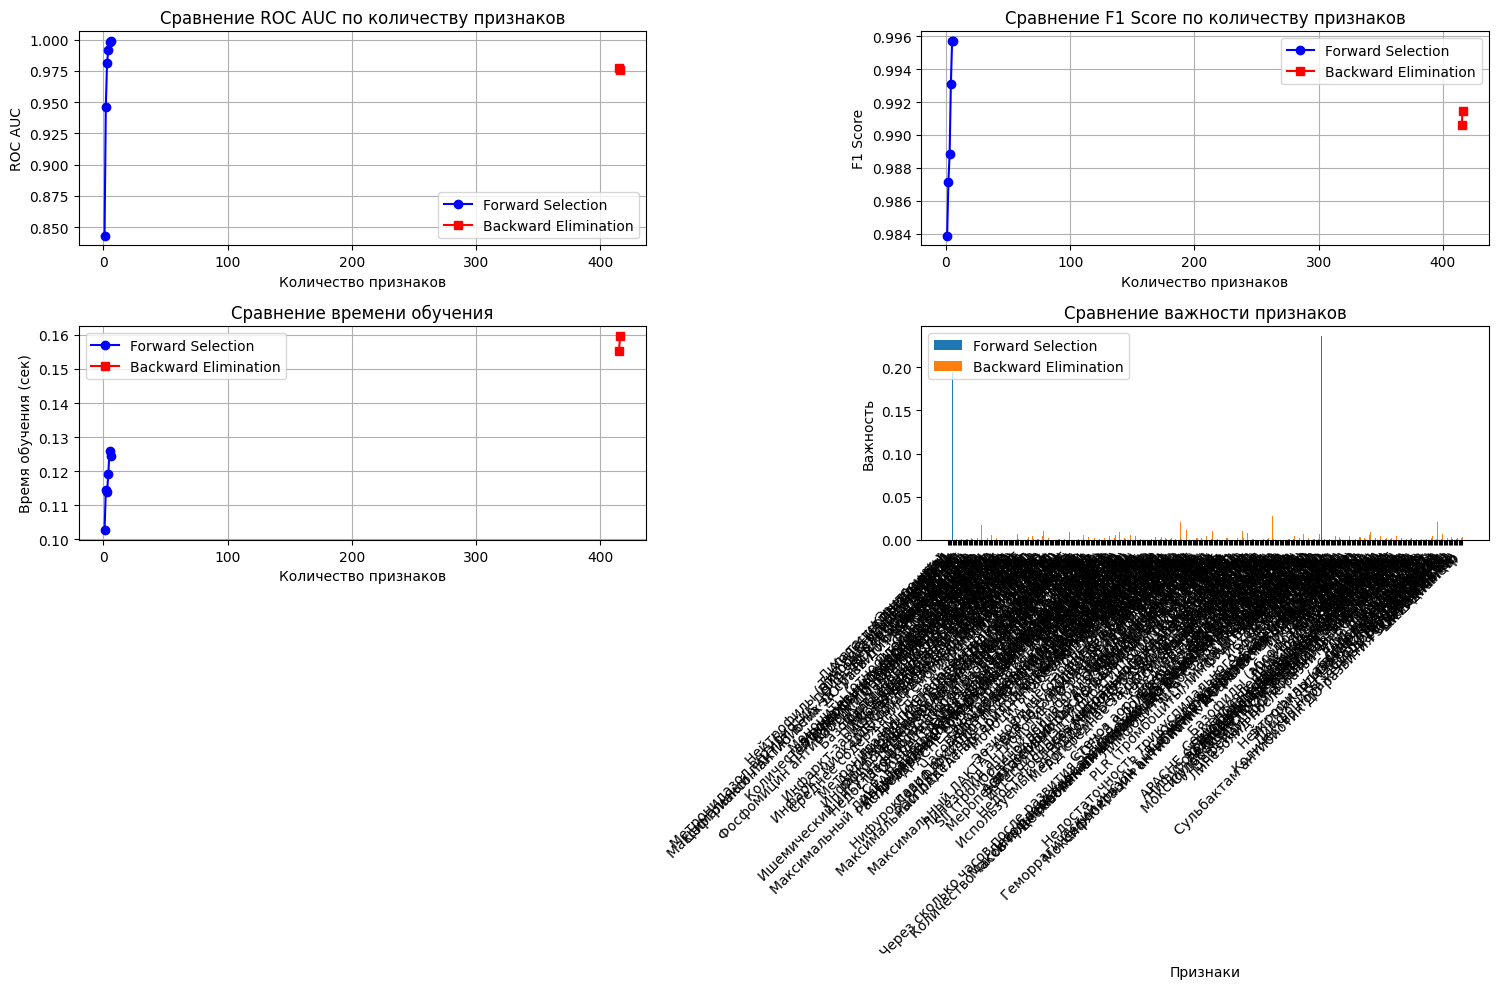


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 6 признаков) ===
По F1 score: 0.5700 (F1=0.9974)
По Youden's J: 0.8000

=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


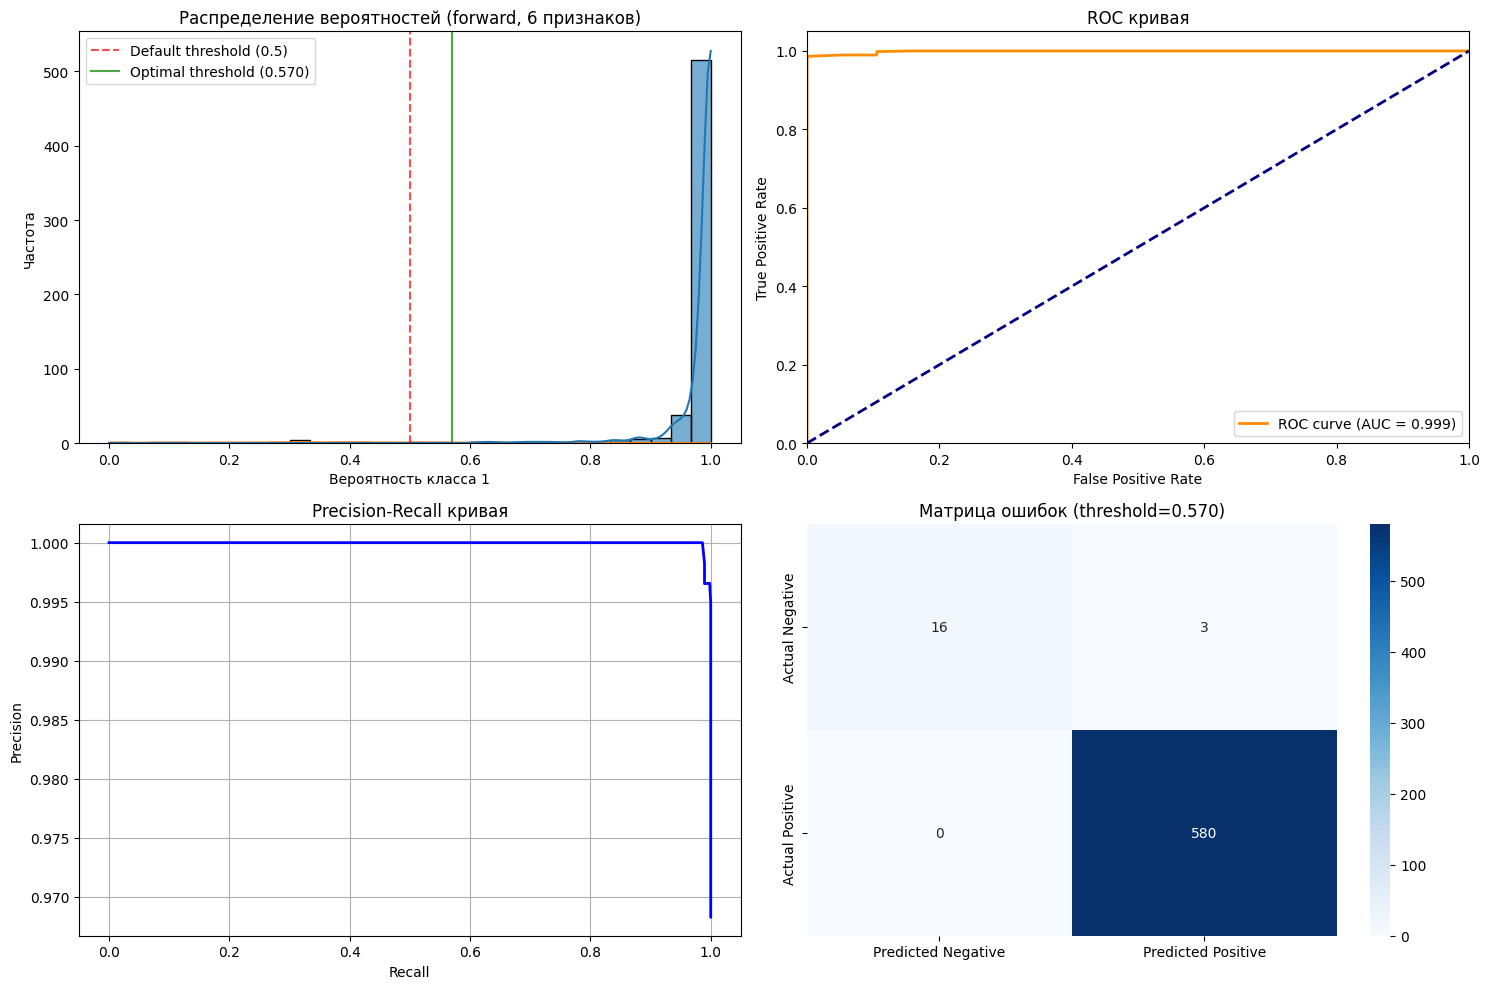

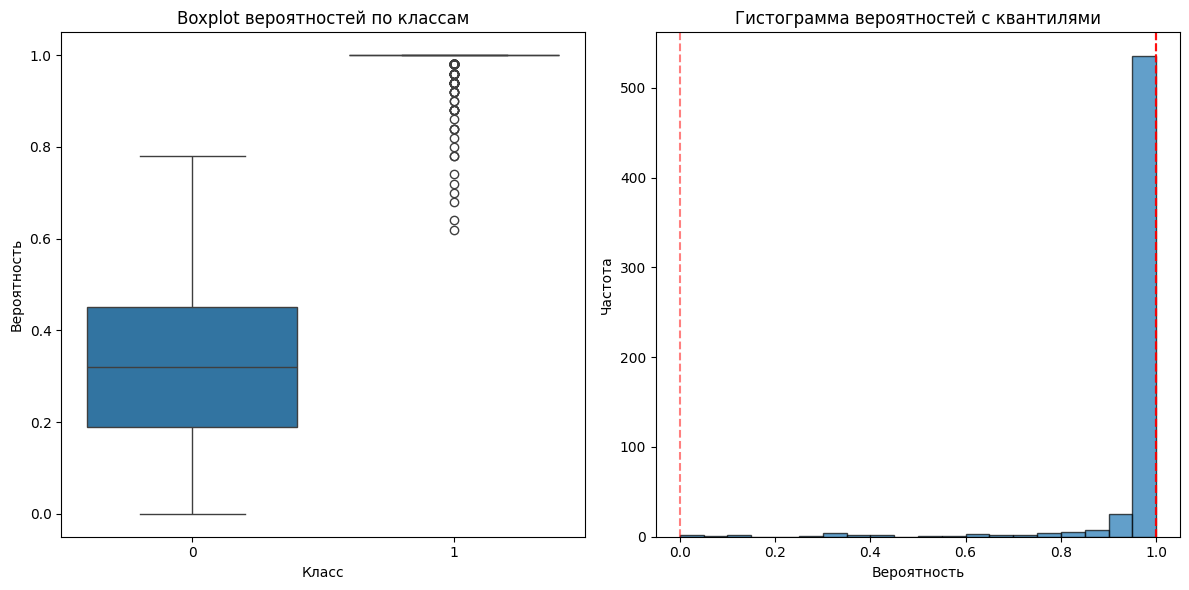


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 6
Лучшая roc_auc: 0.9988
Признаки: ['СДЛА', 'PLR (тромбоциты/лимфоциты абс) (61-239)', 'Отек легких(a)', 'Apache II', 'АПТВ(a)', 'ПТИ(b)']

Важность признаков:
  PLR (тромбоциты/лимфоциты абс) (61-239): 0.2356
  АПТВ(a): 0.2213
  СДЛА: 0.2188
  Apache II: 0.1944
  Отек легких(a): 0.0860
  ПТИ(b): 0.0440
=== Лучшие признаки (backward) ===
Количество признаков: 415
Лучшая roc_auc: 0.9770
Признаки: ['Age', 'Sex', 'STEMI', 'Вид STEMI', 'Инфаркт-зависимая артерия', 'Поражение ствола', 'Количество пораженных сосудов(Syntax)', 'Количество пораженных сосудов(Значимость)', 'TIMI', 'Инфаркт миокарда в анамнезе (<3)', 'Инфаркт миокарда в анамнезе (>3)', 'Инфаркт миокарда со стентированием в анамнезе', 'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе', 'Стентирование в анамнезе', 'Тромболизис', 'Форма ФП', 'Калий', 'Дилатация предсердий', 'ФП b (после чкв)', 'ФП a (в анамнезе)', 'ФП при окс (до чкв)',

In [12]:
# # Генерация данных с большим количеством признакей для демонстрации
# X, y = make_classification(
#     n_samples=1000,
#     n_features=15,  # Уменьшено для демонстрации
#     n_informative=8,
#     n_redundant=4,
#     n_classes=2,
#     random_state=42
# )

# feature_names = [f'feature_{i}' for i in range(15)]
# X_df = pd.DataFrame(X, columns=feature_names)
# y_series = pd.Series(y)

# Инициализация анализатора
analyzer = FeatureSelectionAnalyzer(X, y, test_size=0.2, random_state=42)

# Выбор модели
model_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)  # уменьшено количество деревьев для скорости

# Запуск forward selection БЕЗ early stopping
print("=== FORWARD SELECTION (без early stopping) ===")
forward_features = analyzer.forward_selection(model_rf, max_features=None)  # ограничим до 10 признакей для демонстрации

# Запуск backward elimination БЕЗ early stopping
print("\n=== BACKWARD ELIMINATION (без early stopping) ===")
backward_features = analyzer.backward_elimination(model_rf, min_features=1)

# Сравнение методов
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

# Поиск оптимального порога для лучшей модели forward selection
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')

# Визуализация распределения вероятностей
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')

# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')

# Сохранение результатов
print("\n=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===")
analyzer.save_results_to_excel('feature_selection_analysis_full.xlsx')

print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")

In [13]:
import gc
gc.collect()

  0%|          | 0/10 [38:28<?, ?it/s]


8904